In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [28]:
df = pd.read_csv('dataset.csv')

display(df.head())

,package_name,ecosystem,max_entropy,avg_entropy,eval_count,exec_count,base64_count,network_imports,label
0,3net.js-0.2.4,NPM,5.101039,4.725404,0,0,0,0,0
1,4search-0.0.1,NPM,5.413635,4.760083,0,0,0,0,0
2,a-driver.js-0.9.8-shadowdom2,NPM,5.419901,4.773957,0,0,0,0,0
3,a-frame-router-templates-0.0.4,NPM,7.943876,5.432943,0,0,0,0,0
4,acc-calc-1.0.2,NPM,5.479960,4.919122,0,0,0,0,0


In [29]:
X = df.drop(columns=['package_name', 'ecosystem', 'label'])

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} packages...")
print(f"Testing on {len(X_test)} packages...")

Training on 28289 packages...
Testing on 7073 packages...


In [30]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [31]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malware (1)']))

Model Accuracy: 92.80%

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.92      0.90      0.91      2770
 Malware (1)       0.93      0.95      0.94      4303

    accuracy                           0.93      7073
   macro avg       0.93      0.92      0.92      7073
weighted avg       0.93      0.93      0.93      7073



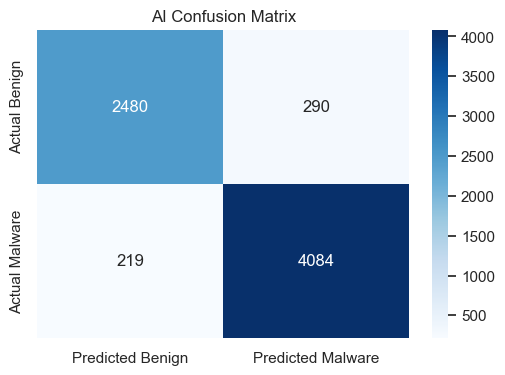

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Benign', 'Predicted Malware'], yticklabels=['Actual Benign', 'Actual Malware'])
plt.title('AI Confusion Matrix')
plt.show()

C:\Users\vladm\AppData\Local\Temp\ipykernel_18144\1576663141.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


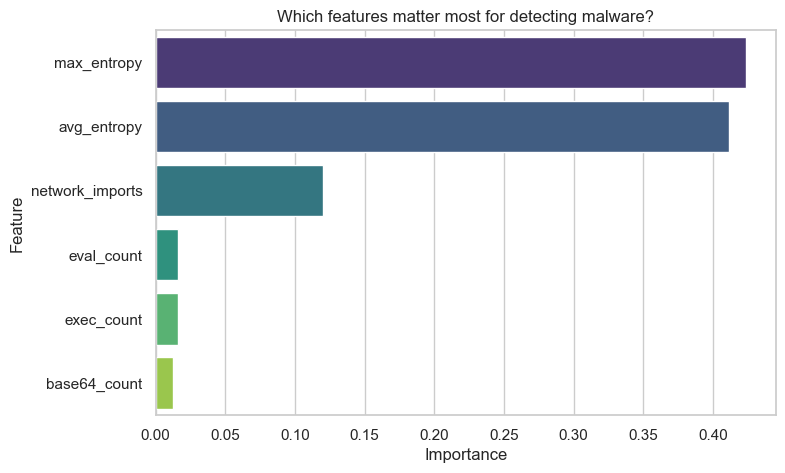

In [33]:
# Extract feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Which features matter most for detecting malware?')
plt.show()

In [34]:
joblib.dump(model, 'malware_classifier.pkl')
print("Model successfully saved as 'malware_classifier.pkl'!")

Model successfully saved as 'malware_classifier.pkl'!
